<a href="https://colab.research.google.com/github/Benard-bb/MOBILE/blob/main/First_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error


In [ ]:
url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
med_ins_cost = pd.read_csv(url)
med_ins_cost.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
med_ins_cost.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
med_ins_cost.isnull()

,age,sex,bmi,children,smoker,region,charges
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1333,False,False,False,False,False,False,False
1334,False,False,False,False,False,False,False
1335,False,False,False,False,False,False,False
1336,False,False,False,False,False,False,False


the following dataset consists of 1338 rows against 7 columns
each of the seven columns represents Age, sex, BMI, number of children, wether the patient is or not a smoker which is the smoker coluumn, the region where the patient lives which is region.
the cost the person paid which is the cost    
AGE
a total of 1338 details were recorded for age with an average of 39 years( to the nearest whole number)
with a minimum age of 18years and maximum age of 64 years     
BMI
a total of 1338 deatils were also collected with no missing values. with an average body mass index of 31 ,a minium 16 and a maximum of 53

  
  
    
      

<Axes: >

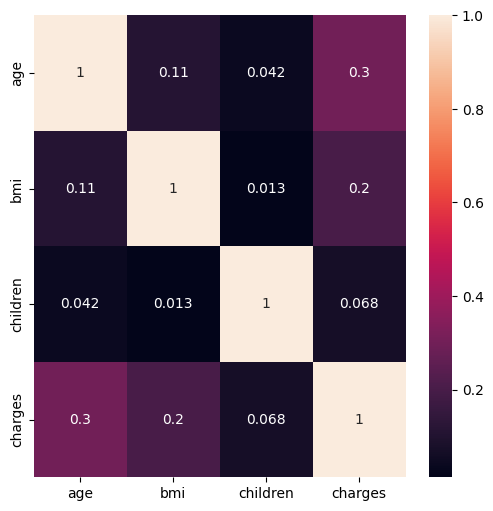

In [ ]:
plt.figure(figsize = (6,6))
sns.heatmap(med_ins_cost.corr(numeric_only= True), annot = True)


the above heatmap shows the correlation between the various variables.
with figures above o showing a positve correlation and below 0 a negatie correlation.
close to 1 shows a strong postive correlation,
close to -1 a strong negatie correlation
and close to 0 shows a very weak negative correlation with 0 meaning no positie correlation.


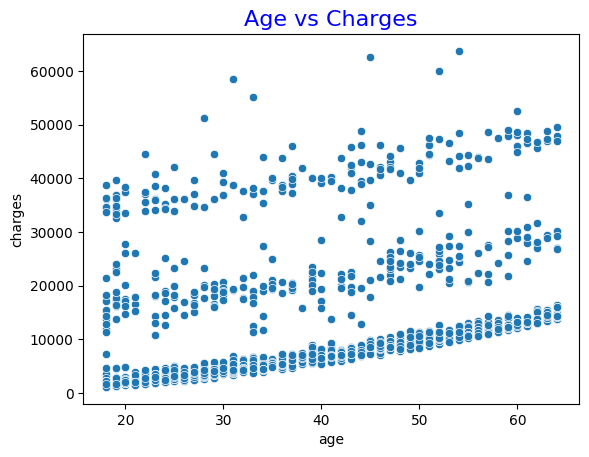

In [ ]:
sns.scatterplot(x = 'age', y = 'charges', data = med_ins_cost)
plt.title('Age vs Charges',
          fontsize = 16,
          color = 'Blue')
plt.show()

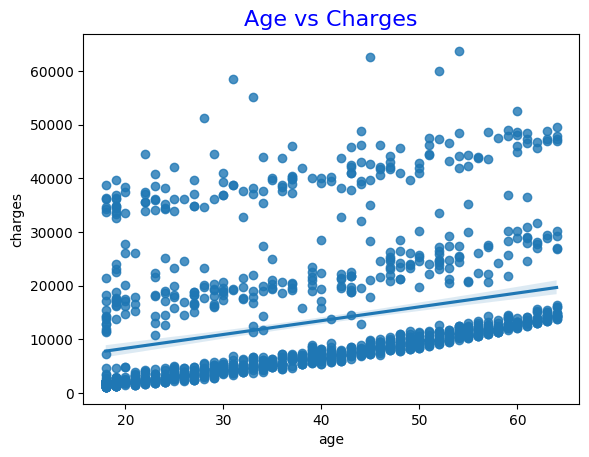

In [ ]:
sns.regplot(x = 'age', y = 'charges', data = med_ins_cost)
plt.title('Age vs Charges',
          fontsize = 16,
          color = 'Blue')
plt.show()


the charts above show a regression line with a gentle positive slope showing that an increase in age affects the cost

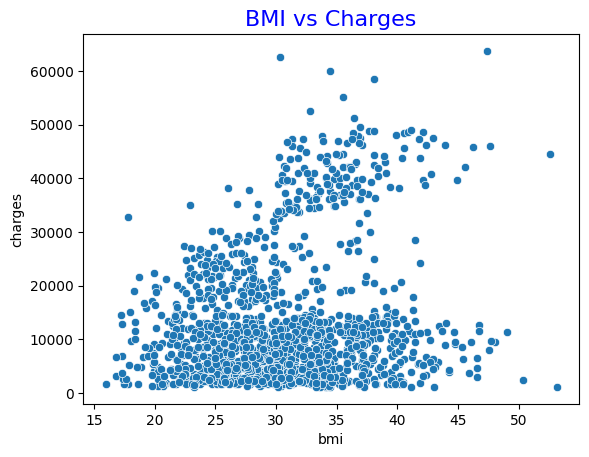

In [ ]:
sns.scatterplot(x = 'bmi', y = 'charges', data = med_ins_cost)
plt.title('BMI vs Charges',
          fontsize = 16,
          color = 'Blue')
plt.show()

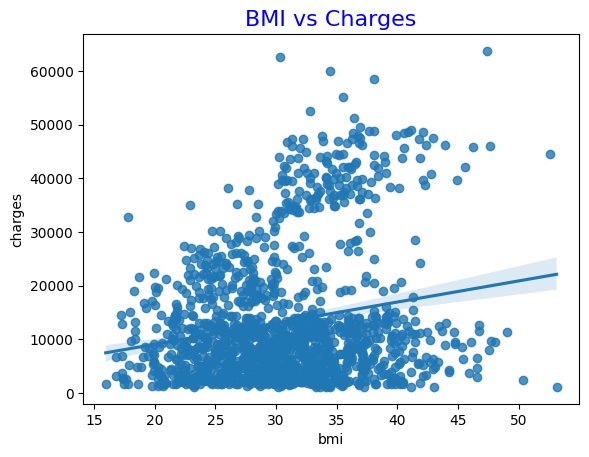

In [ ]:
sns.regplot(x = 'bmi', y = 'charges', data = med_ins_cost)
plt.title('BMI vs Charges',
          fontsize = 16,
          color = 'Blue')
plt.show()

the charts above show a regression line with a gentle positive slope showing that an increase in BMI causes the cost to increase

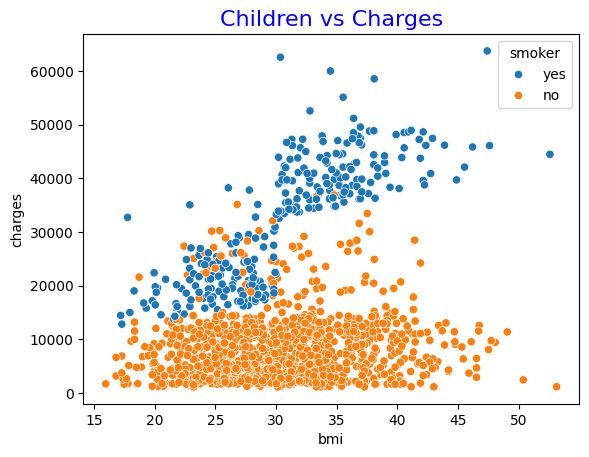

In [ ]:
sns.scatterplot(x = 'bmi', y = 'charges', hue = 'smoker', data = med_ins_cost)
plt.title('bmi vs Charges, taking smoking habit into consideration',
          fontsize = 16,
          color = 'Blue')
plt.show()

this chart above also explains that people that smoke irrespective of the BMI generally pays more

In [ ]:
med_ins_cost.isnull()

,age,sex,bmi,children,smoker,region,charges
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1333,False,False,False,False,False,False,False
1334,False,False,False,False,False,False,False
1335,False,False,False,False,False,False,False
1336,False,False,False,False,False,False,False


In [ ]:
med_ins_cost['sex'] = med_ins_cost['sex'].map({'male': 1, 'female': 0})
med_ins_cost['smoker'] = med_ins_cost['smoker'].map({'yes': 1, 'no': 0})

In [ ]:
features = ['age', 'sex', 'bmi', 'children', 'smoker']
target = 'charges'
X = med_ins_cost[features]
y = med_ins_cost[target]
from sklearn.model_selection import train_test_split
train_X, val_X, train_y, val_y = train_test_split(X, y, test_size = 0.2, random_state = 1)

In [ ]:
def get_mae(max_leaf_nodes, train_X, val_X, train_y, val_y):
    model = DecisionTreeRegressor(max_leaf_nodes = max_leaf_nodes, random_state = 1)
    model.fit(train_X, train_y)
    preds_val = model.predict(val_X)
    mae = mean_absolute_error(val_y, preds_val)
    return mae
for max_leaf_nodes in [5, 50, 500, 5000]:
      my_mae = get_mae(max_leaf_nodes, X_train, X_test, y_train, y_test)
      print("Max leaf nodes: %d  \t\t Mean Absolute Error:  %d" %(max_leaf_nodes, my_mae))

Max leaf nodes: 5  		 Mean Absolute Error:  3271
Max leaf nodes: 50  		 Mean Absolute Error:  2427
Max leaf nodes: 500  		 Mean Absolute Error:  3129
Max leaf nodes: 5000  		 Mean Absolute Error:  3122


In [ ]:
from sklearn.tree import DecisionTreeRegressor
med_ins_cost_model = DecisionTreeRegressor(max_leaf_nodes = 50, random_state = 1)
med_ins_cost_model.fit(train_X, train_y)

DecisionTreeRegressor(max_leaf_nodes=50, random_state=1)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
forest_model = RandomForestRegressor(random_state = 1)
forest_model.fit(train_X, train_y)

RandomForestRegressor(random_state=1)

In [ ]:
print(mean_absolute_error(val_y, forest_model.predict(val_X)))



2734.841527347836


In [ ]:
print(mean_absolute_error(val_y, med_ins_cost_model.predict(val_X)))

2427.1664751479366


For my conclusion i will use the following questions as a guide
1. which features matter most
2. what drives insurance cost up
3.which model performed best and why?

for the features that mattered most,
smoking is top of the list as it greatly affects the insurance cost, the body mass index comes and the age respectively.
the region really didnt affect the insurance cost.
the smoking habits of the individual greatly drives it up
the decision Tree regressor performed better as its mean absolute error was lower as compared the random forests